# 📝 Camera Calibration Instructions

## 🎯 Overview
This notebook implements the camera calibration process from:  
**"Using a Smartphone Device to Quantify Particle Size and Shape Descriptors"**  
by **Daniella Escribano, Carlos Kuncar Medina, and Gonzalo Montalva Alvarado** (2025, in review).

---

## 📋 Step-by-Step Calibration Guide

### 1️⃣ Prepare Your Chessboard Pattern
- 🖨️ **Print** the pattern on a rigid, flat surface
- 🖥️ **OR** display it on a high-resolution screen

✨ **Generate your pattern here:** [Calibration Pattern Generator](https://calib.io/pages/camera-calibration-pattern-generator)

### 2️⃣ Capture Calibration Images
- 📸 - Take **15-20 photos** from various angles and positions.
- 🔄A minimum of 10 well taken images is suggested to obtain good results.
<!-- - 🔄 Rotate the pattern ±45° relative to the camera -->
- 📏 Vary distances between camera and pattern
- 🔍 Ensure the entire pattern is visible in each image
- 💡 Maintain consistent lighting across all images

> *Tip:* For better results, either swing the pattern in front of a stationary camera or move the camera around a fixed pattern.

---

## ⚙️ Critical Parameters

### 📐 Chessboard Configuration
- **Width × Height:** Count the **inner corners**, not squares
  - *Example:* A physical pattern with 10×9 squares has **9×8 inner corners**
  - The pattern in example images has **9×8 inner corners**

<!-- ### 📱 Camera Settings
- **Zoom Level:** Digital zoom used during capture (1x-10x)
  - *Critical:* Calibration is only valid when using the same zoom level
  - Example images use **3x zoom** -->

### 🖼️ Processing Options
- **Downscale Factor:** Reduces the image size to facilitate board detection.
  - *Used in the example:* 2.0 for 12MP images (original size: 4032×3024 px, downscaled to 2016×1512 px for detection).
  - *Higher values:* Faster but less accurate
  - *Lower values:* More accurate but slower

---

## 📊 Visual Examples

<p align="center">
  <img src="https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/1.JPG" width="400">
  <img src="https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/corners_01.JPG" width="400"><br>
  <i><strong>Figure 1.</strong> Left: A single calibration image. Right: The same image with detected chessboard corners.</i>
</p>

<p align="center">
  <img src="https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/Example_calibration.jpg" width="800"><br>
  <i><strong>Figure 2.</strong> Left: Original image with lens distortion. Right: Corrected image using the calibration parameters.</i>
</p>

---

## ⚠️ Important Tips for Success
- 🔆 Ensure **consistent lighting** across all images
- 📐 Capture **both angled and frontal views** for robust calibration
- 📱 Keep your camera settings **consistent** (especially zoom level)
- 🧪 A good calibration should have **reprojection error below 1.0 pixel**
- 🔄 If calibration fails, try increasing the downscale_factor variable to improve detection.
---

In [7]:
#@title 🛠️ Backend Calibration Functions (Click to expand)
#@markdown These are the core functions that power the calibration process.
#@markdown
#@markdown **No need to modify this code** unless you're customizing the algorithm.
#@markdown
#@markdown ### 📋 Included Functionality:
#@markdown - **Image processing:** Corner detection, drawing visualization
#@markdown - **Camera calibration:** Parameter computation, error estimation
#@markdown - **Image correction:** Distortion removal algorithms
#@markdown - **Utility functions:** File handling, example data loading, progress tracking
#@markdown ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
import pickle
import gc
from tqdm.notebook import tqdm
from google.colab import files

# Create necessary directories
os.makedirs('calibration_images', exist_ok=True)
os.makedirs('corners_detected', exist_ok=True)
os.makedirs('calibration_results', exist_ok=True)

def find_next_valid_downscale_factor(max_dimension, downscale_factor):
    """Find a valid downscale factor that works well with the image dimensions."""
    # Convert to float to ensure proper division
    downscale_factor = float(downscale_factor)

    # Calculate what the resulting dimension would be
    target_dimension = max_dimension / downscale_factor

    # Round to nearest integer (practical approach)
    rounded_target = round(target_dimension)

    # Calculate the actual downscale factor that would give this result
    actual_factor = max_dimension / rounded_target

    # Only report if the difference is significant
    if abs(actual_factor - downscale_factor) > 0.05:
        print(f"ℹ️ Fine-tuned downscale factor from {downscale_factor:.2f} to {actual_factor:.2f} for optimal results")
        return actual_factor

    return downscale_factor  # Keep original if close enough

def detect_chessboard_corners(image_path, chessboard_size, downscale_factor):
    """
    Detect chessboard corners in an image.

    Args:
        image_path: Path to the image
        chessboard_size: Tuple (width, height) of inner corners in the chessboard
        downscale_factor: Factor to downscale the image for corner detection

    Returns:
        ret: Boolean indicating if corners were found
        img: Original image
        corners: Detected corners (if found)
        scaled_corners: Corners scaled to original image size (if found)
        scale_x, scale_y: Scale factors
    """
    # Load image
    img = cv2.imread(image_path)
    h1, w1 = img.shape[:2]

    # Calculate the scale factor
    max_dimension = max(h1, w1)
    resolution = max_dimension / downscale_factor

    if max_dimension > resolution:
        scale_factor = resolution / max_dimension
        img_resized = cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LANCZOS4)
    else:
        scale_factor = 1
        img_resized = img

    h, w = img_resized.shape[:2]

    # Convert to grayscale
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (27, 27), 0)  # Gaussian blur to reduce noise

    # Find chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)

    if ret:
        # Refine corner locations
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 1000, 1e-6)
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

        # Calculate scale factors
        scale_x = w1 / w
        scale_y = h1 / h

        # Scale corners to original image size
        scaled_corners = corners.copy()
        scaled_corners[:, :, 0] *= scale_x
        scaled_corners[:, :, 1] *= scale_y

        return ret, img, corners, scaled_corners, scale_x, scale_y, gray.shape[::-1], (w, h)

    return ret, img, None, None, None, None, None, None

def draw_corners_on_image(img, scaled_corners, chessboard_size, quality=None):
    """
    Draw detected corners on the image with highlighting.

    Args:
        img: Original image
        scaled_corners: Detected corners scaled to original image size
        chessboard_size: Tuple (width, height) of inner corners in the chessboard
        quality: Optional quality metric to display

    Returns:
        img_with_corners: Image with drawn corners
    """
    # Create a copy of the image
    img_with_corners = img.copy()

    # Convert corners to proper format
    corners_reshaped = scaled_corners.reshape(-1, 2)
    shape = corners_reshaped.shape[0]

    # Get the outer corners
    top_row = corners_reshaped[0:chessboard_size[0]]
    bottom_row = corners_reshaped[shape - chessboard_size[0]:shape]
    left_column = corners_reshaped[::chessboard_size[0]]
    right_column = corners_reshaped[chessboard_size[0] - 1:shape:chessboard_size[0]]

    outer_corners = np.concatenate((top_row, bottom_row, left_column, right_column))
    outer_corners = outer_corners.astype(int)

    # Create a grayscale image
    img_gray = cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2GRAY)
    img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    # Create a mask
    mask = np.zeros_like(img_color)
    cv2.fillPoly(mask, [outer_corners], (255, 255, 255))

    # Create an image with the patch
    patch_color = np.zeros_like(img_color)
    cv2.fillPoly(patch_color, [outer_corners], (255, 255, 255))

    # Blend the patch with the original image
    img_with_transparency = cv2.addWeighted(img_color, 1, patch_color, 0.5, 0, mask)

    # Draw borders and corners
    cv2.polylines(img_with_transparency, [outer_corners], isClosed=True, color=(20, 219, 141), thickness=14)

    for corner in corners_reshaped:
        cv2.circle(img_with_transparency, (int(corner[0]), int(corner[1])), radius=24, color=(0, 0, 0), thickness=-1)
        cv2.circle(img_with_transparency, (int(corner[0]), int(corner[1])), radius=20, color=(20, 219, 141), thickness=-1)

    # Add quality indicator if provided
    if quality is not None:
        # Place text at bottom left
        quality_color = (0, 200, 0) if quality < 0.5 else (0, 165, 255) if quality < 1.0 else (0, 0, 255)
        quality_text = f"Error: {quality:.4f} px"
        cv2.putText(img_with_transparency, quality_text, (20, img.shape[0] - 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, quality_color, 2)

    return img_with_transparency

def calibrate_camera(image_paths, chessboard_size, downscale_factor, zoom_level, selected_images=None, show_progress=True):
    """
    Calibrate camera using chessboard images.

    Args:
        image_paths: List of paths to calibration images
        chessboard_size: Tuple (width, height) of inner corners in the chessboard
        downscale_factor: Factor to downscale the image for corner detection
        zoom_level: Zoom level used for calibration
        selected_images: List of indices of selected images (if None, use all)
        show_progress: Whether to show progress bar during calibration

    Returns:
        calibration_data: Dictionary containing calibration parameters
        detected_images: List of image paths with detected corners
        corner_images: List of images with drawn corners
        detection_errors: List of errors for each detected image
    """
    if selected_images is not None:
        # Filter image paths based on selected indices
        image_paths = [image_paths[i] for i in selected_images]

    # Initialize arrays for calibration
    obj_points = []  # 3D points in real world space
    img_points = []  # 2D points in image plane
    original_corners = []  # Store the original corners for later use

    # Prepare object points (0,0,0), (1,0,0), (2,0,0) ...
    objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), dtype=np.float32)
    objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)

    # Process images
    detected_images = []
    corner_images = []
    image_sizes = []
    detection_errors = []  # Track errors for each image

    # Check if there are any images
    if not image_paths:
        print("No images provided for calibration. Please upload images first.")
        return None, [], [], []

    # Get the maximum dimension of the first image to adjust downscale_factor
    first_img = cv2.imread(image_paths[0])
    h_orig, w_orig = first_img.shape[:2]
    max_dimension = max(h_orig, w_orig)

    # Adjust downscale_factor if necessary
    original_downscale_factor = downscale_factor
    downscale_factor = find_next_valid_downscale_factor(max_dimension, downscale_factor)
    if downscale_factor != original_downscale_factor:
        print(f"Downscale factor adjusted from {original_downscale_factor} to {downscale_factor} for divisibility.")

    # Create corners_detected directory if it doesn't exist
    os.makedirs("corners_detected", exist_ok=True)

    # Process each image
    if show_progress:
        iterator = tqdm(image_paths, desc="Detecting corners")
    else:
        iterator = image_paths

    for image_path in iterator:
        ret, img, corners, scaled_corners, scale_x, scale_y, gray_size, img_size = detect_chessboard_corners(
            image_path, chessboard_size, downscale_factor
        )

        if ret:
            # Store data for calibration
            obj_points.append(objp)
            img_points.append(corners)
            image_sizes.append(gray_size)

            # Store the scaled corners for later use
            original_corners.append((scaled_corners, image_path))

            # Draw corners on image
            img_with_corners = draw_corners_on_image(img, scaled_corners, chessboard_size)

            # Save image with corners to "corners_detected" directory
            image_filename = os.path.basename(image_path)
            corner_image_path = os.path.join("corners_detected", image_filename)
            cv2.imwrite(corner_image_path, img_with_corners)
            if not show_progress:  # Only print this if not showing progress bar
                print(f"Saved corners image to: {corner_image_path}")

            # Store for display
            detected_images.append(image_path)
            corner_images.append(img_with_corners)
            detection_errors.append(0)  # Placeholder, will be filled later
        else:
            detection_errors.append(None)  # None indicates failed detection

    # Perform calibration if corners were detected
    if obj_points:
        print(f"Calibrating camera with {len(obj_points)} images...")

        # Use the size of the first image with detected corners
        img_size = image_sizes[0]

        # Calibrate camera
        ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
            obj_points, img_points, img_size, None, None
        )

        # Get optimal new camera matrix
        h, w = img_size[::-1]
        newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))

        # Compute reprojection error
        total_error = 0
        for i in range(len(obj_points)):
            img_points2, _ = cv2.projectPoints(obj_points[i], rvecs[i], tvecs[i], mtx, dist)
            error = cv2.norm(img_points[i], img_points2, cv2.NORM_L2) / len(img_points2)
            total_error += error

            # Find the index of this image in detected_images
            image_path = image_paths[obj_points.index(obj_points[i])]
            if image_path in detected_images:
                idx = detected_images.index(image_path)
                detection_errors[idx] = error

        # Update corner images with error information
        for i, (image_path, error) in enumerate(zip(detected_images, detection_errors)):
            if error is not None:
                # Use the original detected corners, not the reprojected ones
                for original_corner, orig_path in original_corners:
                    if orig_path == image_path:
                        # Read the image again to avoid any previous drawings
                        img = cv2.imread(image_path)
                        # Draw corners with quality information
                        corner_images[i] = draw_corners_on_image(img, original_corner, chessboard_size, quality=error)
                        break

        avg_error = total_error / len(obj_points)
        print(f"Average reprojection error: {avg_error:.6f}")

        # Create calibration data dictionary
        calibration_data = {
            'mtx': mtx,
            'dist': dist,
            'rvecs': rvecs,
            'tvecs': tvecs,
            'newcameramtx': newcameramtx,
            'roi': roi,
            'downscale_factor': downscale_factor,
            'avg_error': avg_error,
            'zoom_level': zoom_level,
            'chessboard_size': chessboard_size,
            'calibration_date': time.strftime("%Y-%m-%d %H:%M:%S"),
            'image_count': len(obj_points)
        }

        return calibration_data, detected_images, corner_images, detection_errors
    else:
        print("No chessboard corners were detected in any image. Try adjusting the chessboard size settings or check your images.")
        return None, [], [], []

def save_calibration_data(calibration_data, zoom_level):
    """
    Save calibration data to a pickle file with versioning

    Args:
        calibration_data: Dictionary containing calibration parameters
        zoom_level: Zoom level used during calibration

    Returns:
        filename: Path to the saved calibration file
    """
    os.makedirs('calibration_results', exist_ok=True)
    timestamp = time.strftime("%Y%m%d-%H%M%S")
    filename = f"calibration_results/calibration_zoom{zoom_level}_{timestamp}.pkl"

    with open(filename, 'wb') as f:
        pickle.dump(calibration_data, f)

    return filename

def load_example_images(source_type="calibration"):
    """
    Load example images from GitHub or predefined sources.

    Args:
        source_type: "calibration" for chessboard images or "photos" for sample photos

    Returns:
        image_paths: List of paths to example images
    """
    try:
        # Create directory for example images if it doesn't exist
        example_dir = "example_images"
        os.makedirs(example_dir, exist_ok=True)

        # Subfolder based on source type
        target_dir = os.path.join(example_dir, source_type)
        os.makedirs(target_dir, exist_ok=True)

        # Check if we already have examples
        existing_examples = glob.glob(os.path.join(target_dir, "*.*"))
        if existing_examples:
            print(f"✅ Using {len(existing_examples)} existing example images from {target_dir}")
            return sorted(existing_examples)

        # If no examples, download from GitHub with correct URLs
        print(f"📥 Downloading example {source_type} images...")

        # Example URLs - with correct raw GitHub URLs
        example_urls = {
            "calibration": [
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/1.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/2.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/3.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/4.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/5.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/6.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/7.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/8.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/9.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/10.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/11.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/calibration/12.JPG",
            ],
            "photos": [
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/1X3.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/2X3.JPG",
                "https://raw.githubusercontent.com/ckuncarm/fastGRAINS25/main/data/3X3.JPG",
            ]
        }

        # Download images with improved error handling
        if source_type in example_urls:
            import urllib.request
            from urllib.error import URLError, HTTPError
            downloaded_paths = []

            for i, url in enumerate(example_urls[source_type]):
                try:
                    print(f"  Downloading {url.split('/')[-1]}...")
                    filename = os.path.join(target_dir, f"example_{i+1:02d}.jpg")

                    # Create a Request with a proper User-Agent
                    req = urllib.request.Request(
                        url,
                        data=None,
                        headers={
                            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
                        }
                    )

                    # Try to retrieve with 3-second timeout
                    with urllib.request.urlopen(req, timeout=10) as response, open(filename, 'wb') as out_file:
                        data = response.read()
                        out_file.write(data)

                    downloaded_paths.append(filename)
                    print(f"  ✅ Downloaded: {os.path.basename(filename)}")

                except HTTPError as e:
                    print(f"  ❌ HTTP Error: {e.code} for {url}")
                except URLError as e:
                    print(f"  ❌ URL Error: {e.reason} for {url}")
                except Exception as e:
                    print(f"  ❌ Error downloading {url}: {str(e)}")

            # If we couldn't download any images, try OpenCV samples as fallback
            if not downloaded_paths and source_type == "calibration":
                print("  Trying OpenCV sample images as fallback...")
                fallback_urls = [
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left02.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left03.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left04.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left05.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left06.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left07.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left08.jpg",
                    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left09.jpg",
                ]

                for i, url in enumerate(fallback_urls):
                    try:
                        filename = os.path.join(target_dir, f"opencv_{i+1:02d}.jpg")
                        urllib.request.urlretrieve(url, filename)
                        downloaded_paths.append(filename)
                        print(f"  ✅ Downloaded fallback: {os.path.basename(filename)}")
                    except Exception as e:
                        print(f"  ⚠️ Error downloading fallback {url}: {str(e)}")

            if downloaded_paths:
                print(f"✅ Downloaded {len(downloaded_paths)} example {source_type} images")
                return sorted(downloaded_paths)
            else:
                # Create synthetic chessboard pattern as last resort
                print("❌ Could not download any example images")
                print("Creating synthetic chessboard pattern as last resort...")

                # Create a synthetic chessboard pattern
                pattern_size = (800, 600)
                square_size = 100
                pattern = np.zeros((pattern_size[1], pattern_size[0], 3), dtype=np.uint8)
                pattern.fill(255)

                # Draw the chessboard
                for i in range(0, pattern_size[1], square_size):
                    for j in range(0, pattern_size[0], square_size):
                        if ((i // square_size) + (j // square_size)) % 2 == 0:
                            cv2.rectangle(pattern, (j, i), (j + square_size, i + square_size), (0, 0, 0), -1)

                # Save the pattern
                synthetic_path = os.path.join(target_dir, "synthetic_chessboard.jpg")
                cv2.imwrite(synthetic_path, pattern)
                print(f"✅ Created synthetic chessboard pattern: {synthetic_path}")

                return [synthetic_path]
        else:
            print(f"❌ Unknown example type: {source_type}")
            return []

    except Exception as e:
        print(f"❌ Error loading example images: {str(e)}")
        print("Please try uploading your own images instead.")
        return []

def correct_image_distortion_zoom(image_paths, calibration_file_path, zoom_factor, show_progress=True):
    """
    Correct distortion in multiple images using calibration data with progress tracking.

    Args:
        image_paths: List of paths to images to correct
        calibration_file_path: Path to calibration data file
        zoom_factor: Factor to adjust the zoom level
        show_progress: Whether to show progress bar

    Returns:
        output_folder: Path to folder containing corrected images
    """
    try:
        # Load calibration data
        with open(calibration_file_path, 'rb') as file:
            calibration_data = pickle.load(file)

        mtx = calibration_data['mtx']
        dist = calibration_data['dist']
        downscale_factor = calibration_data.get('downscale_factor', 1.0)

        # Extract the directory of the first image
        first_image_dir = os.path.dirname(image_paths[0])
        # Extract the folder name
        folder_name = os.path.basename(first_image_dir)
        # Create new folder name
        new_folder_name = folder_name + "_Undistorted"
        # Get the parent directory of the images_path
        parent_dir = os.path.dirname(first_image_dir)
        # Construct the path for the new folder
        new_folder_path = os.path.join(parent_dir, new_folder_name)
        # Check if the new folder exists, if not, create it
        if not os.path.exists(new_folder_path):
            os.makedirs(new_folder_path)

        # Create progress bar
        if show_progress:
            progress_bar = tqdm(total=len(image_paths), desc="Correcting images")

        for image_path in image_paths:
            try:
                # Support for multiple image formats
                try:
                    img = cv2.imread(image_path)
                    if img is None:
                        # Try reading with special handling for RAW formats
                        from rawpy import imread as raw_imread
                        with raw_imread(image_path) as raw:
                            img = raw.postprocess()
                except Exception as e:
                    print(f"❌ Error reading image {os.path.basename(image_path)}: {str(e)}")
                    if show_progress:
                        progress_bar.update(1)
                    continue

                h, w = img.shape[:2]

                # Resize image if necessary
                max_dimension = max(h, w)
                resolution = max_dimension / downscale_factor

                if max_dimension > resolution:
                    scale_factor = resolution / max_dimension
                    img_resized = cv2.resize(img, None, fx=scale_factor, fy=scale_factor,
                                           interpolation=cv2.INTER_LANCZOS4)
                else:
                    img_resized = img

                h, w = img_resized.shape[:2]
                w1, h1 = int(downscale_factor * w), int(downscale_factor * h)

                # Adjust the camera matrix for the zoom factor
                zoomed_mtx = mtx.copy()
                zoomed_mtx[0, 0] *= zoom_factor  # fx
                zoomed_mtx[1, 1] *= zoom_factor  # fy

                newcameramtx, roi = cv2.getOptimalNewCameraMatrix(zoomed_mtx, dist, (w, h), 1, (w1, h1))

                mapx, mapy = cv2.initUndistortRectifyMap(zoomed_mtx, dist, None, newcameramtx, (w1, h1), 5)
                dst = cv2.remap(img_resized, mapx, mapy, cv2.INTER_LANCZOS4)

                # Attempt to get a valid ROI for cropping
                x, y, w, h = roi
                if x >= 0 and y >= 0 and w > 0 and h > 0 and x + w <= dst.shape[1] and y + h <= dst.shape[0]:
                    dst_cropped = dst[y:y+h, x:x+w]
                else:
                    # If ROI is invalid, apply a safe crop
                    border = int(dst.shape[0] * 0.05)  # 5% border
                    if border * 2 < dst.shape[0] and border * 2 < dst.shape[1]:
                        dst_cropped = dst[border:-border, border:-border]
                    else:
                        dst_cropped = dst

                # Save the corrected image
                image_name = os.path.basename(image_path)
                base, ext = os.path.splitext(image_name)
                # Force JPG format for consistent output
                new_image_path = os.path.join(new_folder_path, f"{base}.jpg")
                cv2.imwrite(new_image_path, dst_cropped)

                # Update progress bar
                if show_progress:
                    progress_bar.update(1)

                # Explicit cleanup to minimize memory usage
                del img, img_resized, dst, dst_cropped
                gc.collect()

            except Exception as e:
                print(f"⚠️ Error processing image {os.path.basename(image_path)}: {str(e)}")
                if show_progress:
                    progress_bar.update(1)

        # Close progress bar
        if show_progress:
            progress_bar.close()

        return new_folder_path

    except Exception as e:
        print(f"❌ Error during distortion correction: {str(e)}")
        if show_progress and 'progress_bar' in locals():
            progress_bar.close()
        return None

def display_image_grid(image_paths, title, max_images=6, cols=3):
    """
    Display a grid of images with titles.

    Args:
        image_paths: List of paths to images
        title: Title for the grid
        max_images: Maximum number of images to display
        cols: Number of columns in the grid
    """
    if not image_paths:
        print(f"No images to display for: {title}")
        return

    # Limit number of images to display
    display_paths = image_paths[:max_images]
    rows = (len(display_paths) + cols - 1) // cols

    print(f"\n{title} ({len(image_paths)} total):")

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))

    # Handle case where there's only one row
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    elif rows == 1:
        axes = axes.reshape(1, -1)

    for i, ax in enumerate(axes.flat):
        if i < len(display_paths):
            img = cv2.imread(display_paths[i])
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(os.path.basename(display_paths[i]), fontsize=9)
            else:
                ax.text(0.5, 0.5, "Error loading image", ha='center', va='center', fontsize=10)
                ax.set_title(os.path.basename(display_paths[i]), fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


✅ Using 12 existing example images from example_images/calibration

📸 Example Calibration Images (12 total):


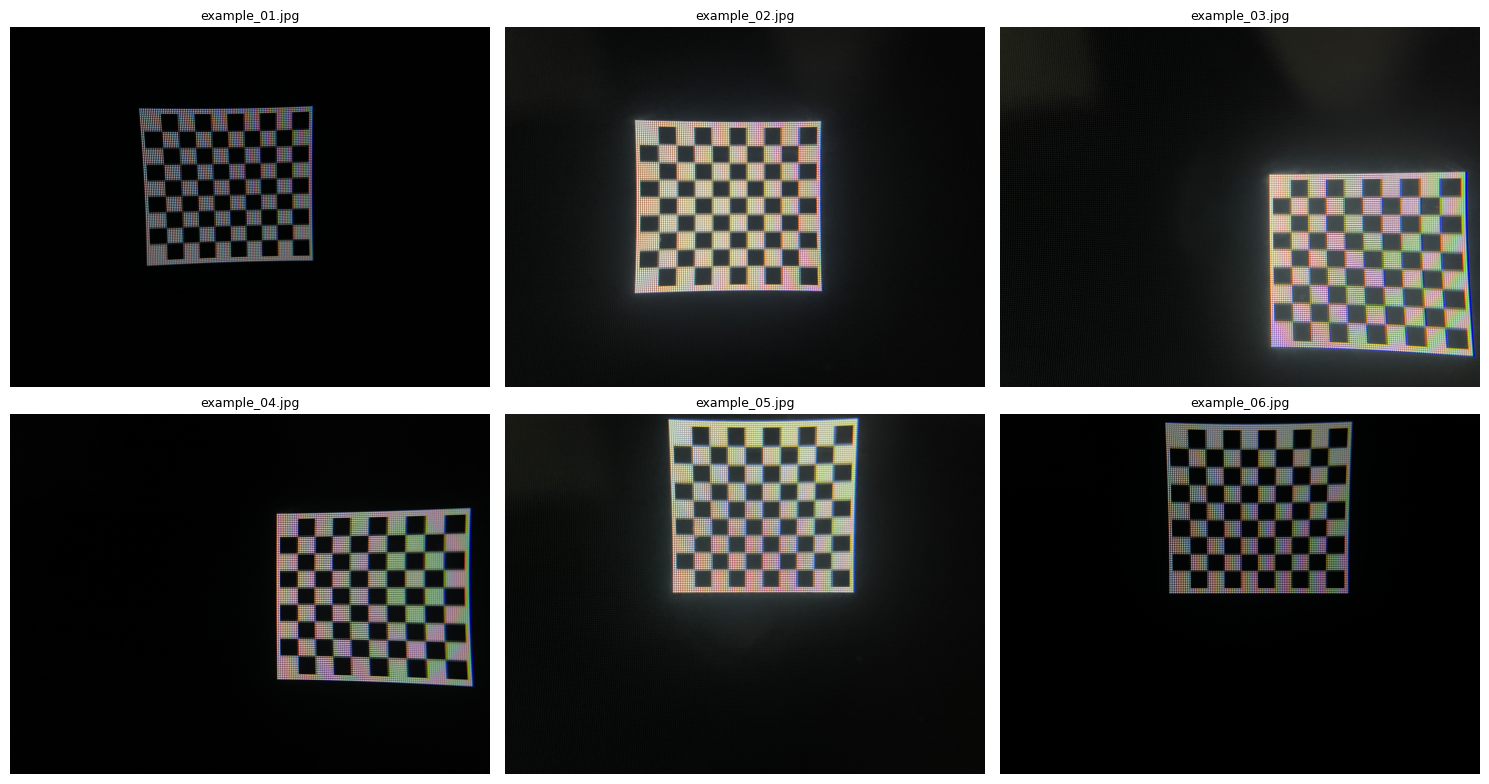


🔍 Analyzing first image with current settings...


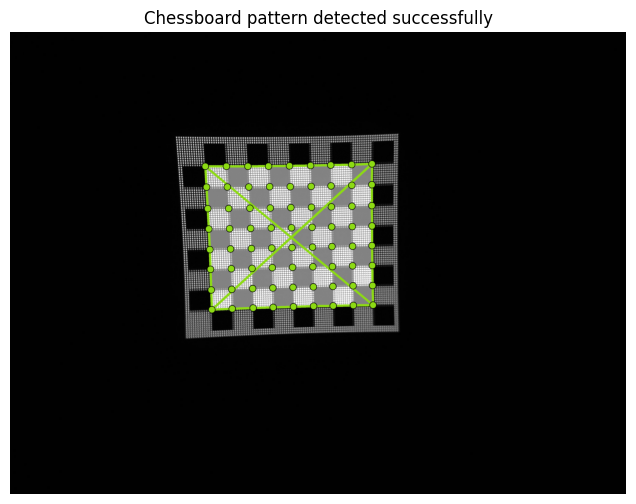

✅ Pattern detection successful with 9×8 corners
   You can proceed with calibration


In [9]:

#@title 📤 Upload Calibration Images
#@markdown ## Camera Calibration - Image Upload
#@markdown Upload multiple photos of a chessboard pattern from different angles for calibration
from google.colab import files

#@markdown ### 🔄 Image Source
use_example_images = True #@param {type:"boolean"}

# Create directory for calibration images
os.makedirs('calibration_images', exist_ok=True)

# Handle example images loading
if use_example_images:
    # Load example calibration images
    calibration_image_paths = load_example_images("calibration")
    display_image_grid(calibration_image_paths, "📸 Example Calibration Images")

else:
    # Display upload widget with instructions
    print("📋 Guidelines for calibration images:")
    print("1. Take 10-20 photos of a chessboard pattern")
    print("2. Capture the pattern from different angles and distances")
    print("3. Ensure the entire pattern is visible in each image")
    print("4. Use good lighting conditions")
    print("5. Keep the camera settings consistent for all images")

    # Display upload button
    print("\n📤 Upload your calibration images when prompted...")
    uploaded = files.upload()

    if uploaded:
        # Process uploaded files
        try:
            # Save uploaded files and get their paths
            for name, content in uploaded.items():
                # Save to destination folder
                dest_path = os.path.join('calibration_images', name)
                with open(dest_path, 'wb') as f:
                    f.write(content)

                # Delete original file if it exists in current directory
                original_path = os.path.join('.', name)
                if os.path.exists(original_path):
                    os.remove(original_path)

            # Get updated list of images
            calibration_image_paths = glob.glob(os.path.join('calibration_images', '*'))
            print(f"✅ Successfully uploaded {len(uploaded)} images. Total images available: {len(calibration_image_paths)}")

            # Show thumbnails of uploaded images
            if calibration_image_paths:
                display_image_grid(calibration_image_paths, "📸 Uploaded Calibration Images")
        except Exception as e:
            print(f"❌ Error processing uploaded images: {str(e)}")
            print("Please try uploading again")
    else:
        print("No images were uploaded. Please try again or use example images.")

#@markdown ## ♟️ Chessboard Pattern Settings
#@markdown Configure these settings to match your chessboard pattern

# #@markdown *Note: For a standard 8×8 chess board, use width=7, height=7 (inner corners, not squares)*

chessboard_width = 9 #@param {type:"slider", min:5, max:15, step:1}
chessboard_height = 8 #@param {type:"slider", min:5, max:15, step:1}
chessboard_size = (chessboard_width, chessboard_height)

#@markdown ## ⚙️ Advanced Parameters
#@markdown These settings affect processing speed and output quality

downscale_factor = 2 #@param {type:"slider", min:1.0, max:4.0, step:0.5}
zoom_level = 1 #@param {type:"slider", min:0.5, max:3.0, step:0.1}

#@markdown ## Pre-calibration Check
if 'calibration_image_paths' in locals() and calibration_image_paths:
    # Validate first image with current chessboard settings
    first_image = calibration_image_paths[0]

    # Display analysis result
    print("\n🔍 Analyzing first image with current settings...")
    ret, img, corners, scaled_corners, _, _, _, _ = detect_chessboard_corners(
        first_image, chessboard_size, downscale_factor
    )

    if ret:
        # Draw corners on image and display
        img_with_corners = draw_corners_on_image(img, scaled_corners, chessboard_size)
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
        plt.title("Chessboard pattern detected successfully", fontsize=12)
        plt.axis('off')
        plt.show()

        print(f"✅ Pattern detection successful with {chessboard_width}×{chessboard_height} corners")
        print("   You can proceed with calibration")
    else:
        # Show the image with error message
        plt.figure(figsize=(8, 6))
        if img is not None:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("❌ Could not detect chessboard pattern with current settings", fontsize=14)
        plt.figtext(0.5, 0.01, f"Try adjusting width={chessboard_width}, height={chessboard_height}",
                   fontsize=12, ha='center', color='red')
        plt.axis('off')
        plt.show()

        print("❌ Chessboard pattern not detected with current settings")
        print("   Suggestions:")
        print("   - Try different chessboard dimensions (adjust width/height)")
        print("   - Check if the entire chessboard is visible in the image")
        print("   - Ensure good lighting and focus in the images")
else:
    print("❌ No images available for pre-calibration check")
    print("   Please upload images or load examples first")


Starting calibration with 12 images...
Using chessboard size: 9×8


Detecting corners:   0%|          | 0/12 [00:00<?, ?it/s]

Calibrating camera with 12 images...
Average reprojection error: 0.160454
✅ Calibration completed successfully!
   Data saved to: calibration_results/calibration_zoom1_20250327-122453.pkl

📊 Calibration Quality Metrics:
   Mean Reprojection Error: 0.1605 pixels
   Calibration Quality: Excellent


<ipython-input-10-39a30727515c>:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


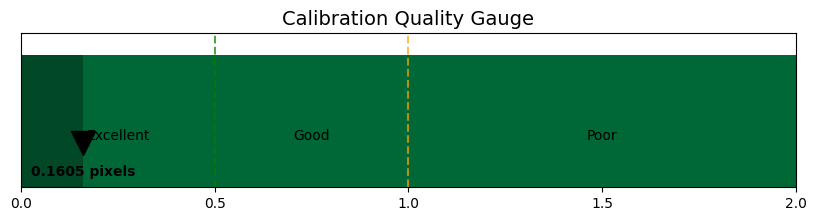


🔍 Corner Detection Results:


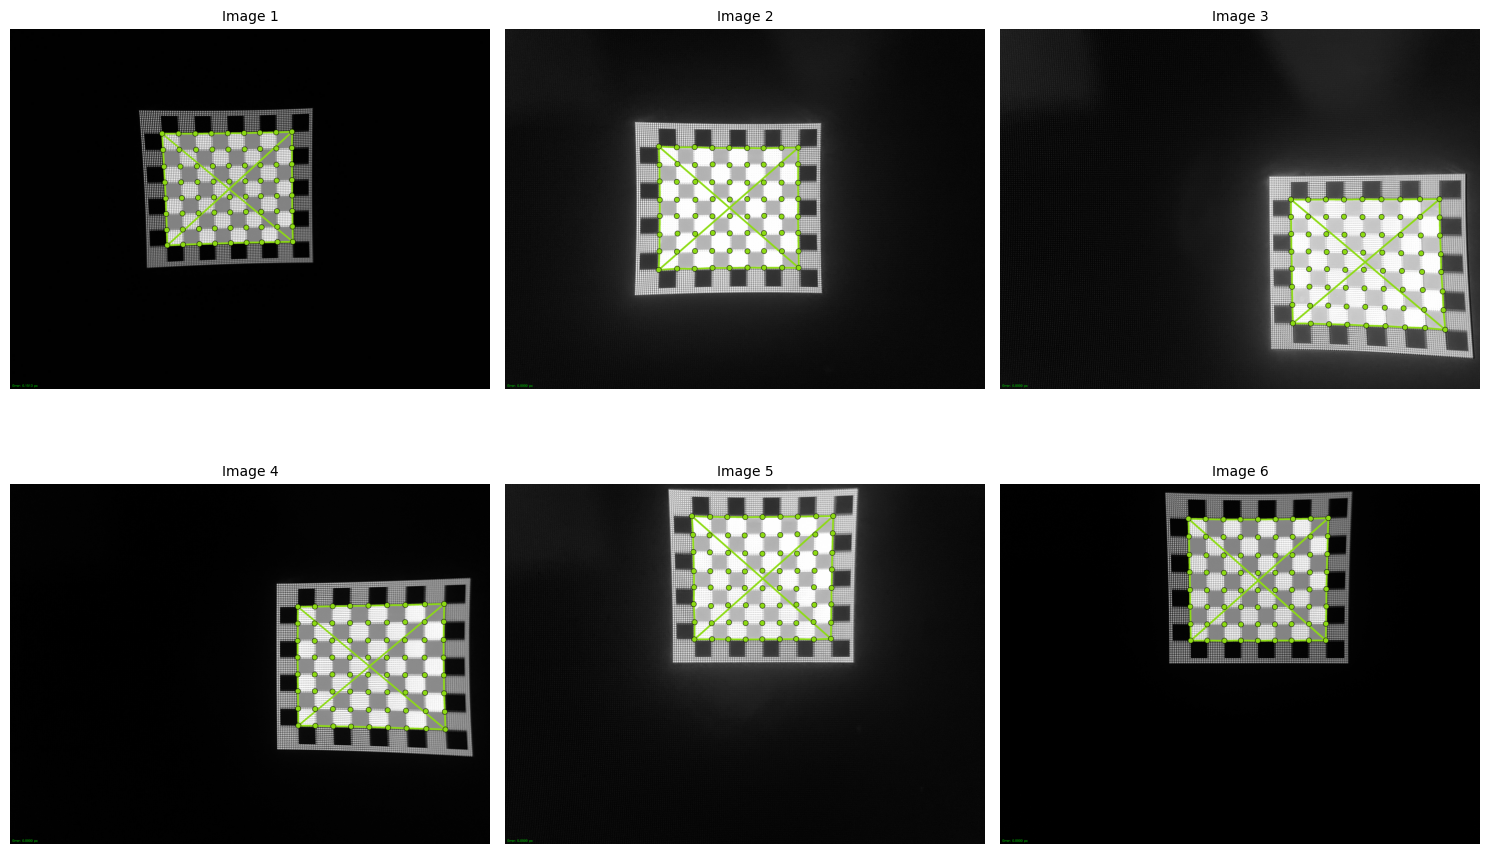


⬇️ Download your calibration file:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⏭️ Ready to proceed to image distortion correction!


In [10]:

#@title 🔍 Run Calibration and Save Results
#@markdown ## Camera Calibration Process
#@markdown This will detect chessboard corners and calculate camera parameters

run_calibration = True #@param {type:"boolean"}

if run_calibration:
    if not 'calibration_image_paths' in locals() or not calibration_image_paths:
        print("❌ Error: No calibration images found. Please upload images or load examples first.")
    else:
        try:
            print(f"Starting calibration with {len(calibration_image_paths)} images...")
            print(f"Using chessboard size: {chessboard_width}×{chessboard_height}")

            # Detect chessboard corners and calibrate camera with progress tracking
            calibration_data, detected_images, corner_images, detection_errors = calibrate_camera(
                calibration_image_paths,
                chessboard_size,
                downscale_factor,
                zoom_level,
                show_progress=True
            )

            if calibration_data:
                # Save calibration data
                calibration_file_path = save_calibration_data(calibration_data, zoom_level)
                print(f"✅ Calibration completed successfully!")
                print(f"   Data saved to: {calibration_file_path}")
                current_calibration_file = calibration_file_path

                # Display calibration quality metrics
                avg_error = calibration_data['avg_error']
                print(f"\n📊 Calibration Quality Metrics:")
                print(f"   Mean Reprojection Error: {avg_error:.4f} pixels")

                # Evaluate calibration quality
                if avg_error < 0.5:
                    quality = "Excellent"
                    color = "green"
                elif avg_error < 1.0:
                    quality = "Good"
                    color = "orange"
                else:
                    quality = "Poor"
                    color = "red"

                print(f"   Calibration Quality: {quality}")

                # Display calibration quality gauge
                from matplotlib import cm
                plt.figure(figsize=(10, 2))
                ax = plt.gca()
                cmap = cm.get_cmap('RdYlGn_r')
                norm = plt.Normalize(0, 2)

                # Draw gauge bar
                plt.barh([0], [2], color=cmap(norm(np.linspace(0, 2, 100))))
                plt.barh([0], [avg_error], color='black', alpha=0.3)

                # Add markers
                plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.7)
                plt.axvline(x=1.0, color='orange', linestyle='--', alpha=0.7)
                plt.text(0.25, 0, 'Excellent', ha='center', va='bottom')
                plt.text(0.75, 0, 'Good', ha='center', va='bottom')
                plt.text(1.5, 0, 'Poor', ha='center', va='bottom')

                # Add error pointer
                plt.scatter([avg_error], [0], color='black', s=300, marker='v', zorder=5)
                plt.text(avg_error, -0.1, f'{avg_error:.4f} pixels', ha='center', va='top', fontweight='bold')

                # Format plot
                plt.xlim(0, 2)
                plt.ylim(-0.2, 0.5)
                plt.title('Calibration Quality Gauge', fontsize=14)
                plt.xticks([0, 0.5, 1.0, 1.5, 2.0])
                plt.yticks([])
                plt.show()

                # Show detection results in a grid
                print("\n🔍 Corner Detection Results:")
                fig, axes = plt.subplots(2, 3, figsize=(15, 10))
                axes = axes.flatten()

                # Show up to 6 images with corners
                for i, ax in enumerate(axes):
                    if i < len(corner_images):
                        ax.imshow(cv2.cvtColor(corner_images[i], cv2.COLOR_BGR2RGB))

                        # # Get error for this image
                        # error = detection_errors[i] if i < len(detection_errors) else None
                        # error_str = f" (Error: {error:.4f} px)" if error is not None else ""

                        ax.set_title(f"Image {i+1}", fontsize=10)
                    ax.axis('off')

                plt.tight_layout()
                plt.show()

                # Provide the download link for the calibration file
                print("\n⬇️ Download your calibration file:")
                files.download(calibration_file_path)

                print("\n⏭️ Ready to proceed to image distortion correction!")
            else:
                print("❌ Calibration failed. Check your images and settings.")
                print("   Suggestions:")
                print("   - Try different chessboard dimensions")
                print("   - Ensure good lighting conditions")
                print("   - Make sure the entire chessboard is visible in images")
                print("   - Try uploading more images from different angles")
        except Exception as e:
            print(f"❌ Error during calibration: {str(e)}")
else:
    print("Set 'Run Calibration' to True when you're ready to start the calibration process.")


✅ Using calibration file from previous step: calibration_zoom1_20250327-112726.pkl
📥 Downloading example photos images...
  ✅ Downloaded: example_01.jpg
  ✅ Downloaded: example_02.jpg
  ✅ Downloaded: example_03.jpg
✅ Downloaded 3 example photos images

📸 Example Images to Correct (3 total):


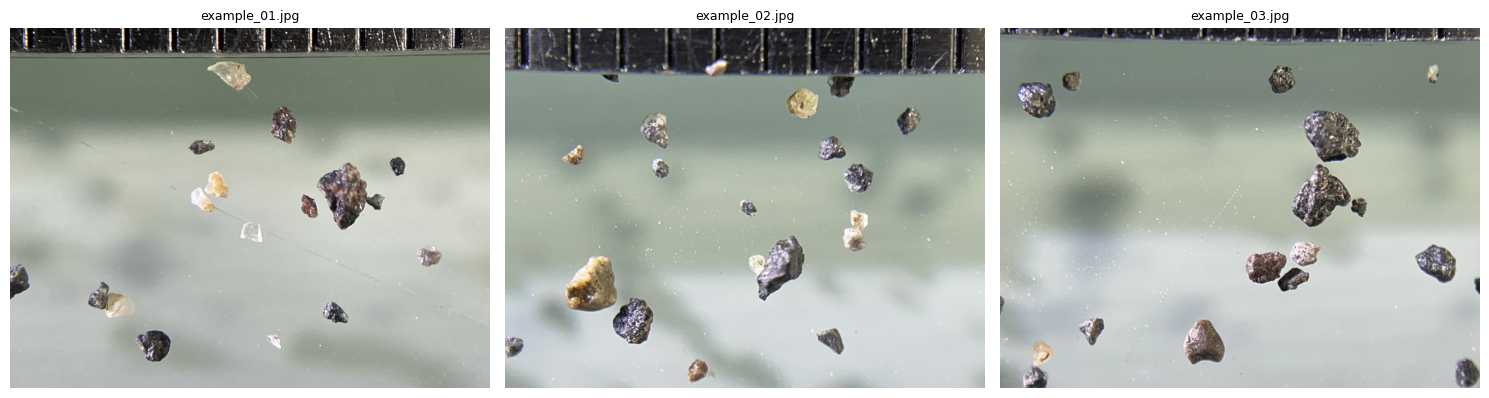


📊 Calibration Information:
   Average Error: 0.0562 pixels
   Date Created: 2025-03-27 11:27:26
   Images Used: 12
   Chessboard Size: 9×8
Using zoom factor 3x for example images.
🔄 Processing 3 images with zoom factor 3x...
Cleaning previous output folder: example_images/calibration_Undistorted


Correcting images:   0%|          | 0/3 [00:00<?, ?it/s]


🔧 All Corrected Images (3 total):


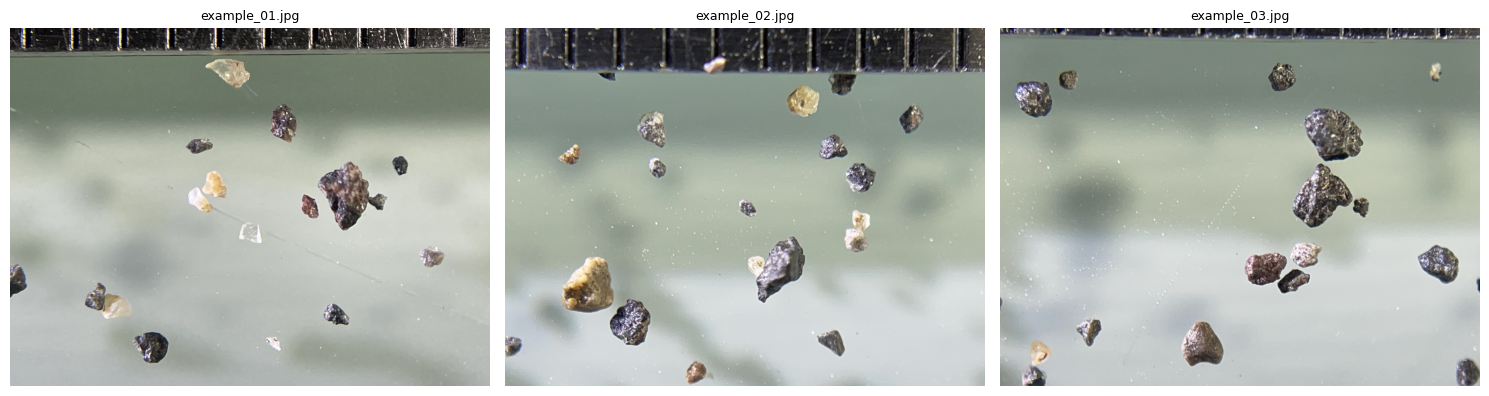

✅ Successfully processed 3 images
📁 Corrected images saved to: example_images/photos_Undistorted

⬇️ Download all corrected images:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
import os, glob, pickle
import cv2
import matplotlib.pyplot as plt

#@title 🔧 Correct Distortion in Your Images
#@markdown ## 🔍 Image Distortion Correction
#@markdown Upload your images and correct distortion using calibration data

#@markdown ### 📁 Load Calibration Data
#@markdown Either upload a calibration file (.pkl) or use the one from the previous step

use_existing_calibration = True #@param {type:"boolean"}

if use_existing_calibration and 'current_calibration_file' in locals() and current_calibration_file:
    print(f"✅ Using calibration file from previous step: {os.path.basename(current_calibration_file)}")
    calibration_file_path = current_calibration_file
else:
    print("📤 Upload your calibration file (.pkl)")
    calibration_file = files.upload()
    if calibration_file:
        calibration_file_path = list(calibration_file.keys())[0]
        print(f"✅ Uploaded calibration file: {calibration_file_path}")
    else:
        calibration_file_path = None
        print("❌ No calibration file uploaded")

#@markdown ### 📸 Images to Correct
#@markdown Choose your source for images to correct

#@markdown #### Image Source
image_source = "Use example images" #@param ["Upload my own images", "Use example images", "Use calibration images"]

# Handle image selection based on source
if calibration_file_path:
    if image_source == "Upload my own images":
        print("📤 Upload the images you want to undistort")
        uploaded_files = files.upload()
        if uploaded_files:
            # Create temporary directory for uploaded images
            temp_input_dir = "images_to_correct"
            if os.path.exists(temp_input_dir):
                for file in glob.glob(os.path.join(temp_input_dir, "*")):
                    try:
                        os.remove(file)
                    except:
                        print(f"Warning: Could not remove {file}")
            else:
                os.makedirs(temp_input_dir)
            input_paths = []
            for name, content in uploaded_files.items():
                file_path = os.path.join(temp_input_dir, name)
                with open(file_path, 'wb') as f:
                    f.write(content)
                input_paths.append(file_path)
                if os.path.exists(name):
                    try:
                        os.remove(name)
                    except:
                        print(f"Warning: Could not remove {name} from current directory")
            print(f"✅ Uploaded {len(input_paths)} images for correction")
            display_image_grid(input_paths, "📸 Images to Correct")
            images_to_correct = uploaded_files
        else:
            input_paths = []
            print("❌ No images uploaded for correction")
    elif image_source == "Use example images":
        # Load example images
        input_paths = load_example_images("photos")
        display_image_grid(input_paths, "📸 Example Images to Correct")
    elif image_source == "Use calibration images":
        # Use the calibration images
        if 'calibration_image_paths' in locals() and calibration_image_paths:
            input_paths = calibration_image_paths
            display_image_grid(input_paths[:6], "📸 Calibration Images to Correct")
        else:
            input_paths = []
            print("❌ No calibration images available")

    if calibration_file_path:
        try:
            with open(calibration_file_path, 'rb') as f:
                cal_data = pickle.load(f)
            print("\n📊 Calibration Information:")
            print(f"   Average Error: {cal_data.get('avg_error', 'N/A'):.4f} pixels")
            print(f"   Date Created: {cal_data.get('calibration_date', 'N/A')}")
            print(f"   Images Used: {cal_data.get('image_count', 'N/A')}")
            cb_size = cal_data.get('chessboard_size', (0, 0))
            if cb_size[0] > 0:
                print(f"   Chessboard Size: {cb_size[0]}×{cb_size[1]}")
        except Exception as e:
            print(f"⚠️ Error reading calibration info: {str(e)}")
else:
    input_paths = []
    print("Please upload a calibration file first.")

#@markdown ### ⚙️ Correction Parameters
#@markdown **Zoom Factor:** Digital zoom level at which the photographs were taken. This value is used to correct the distortion corresponding to the zoom setting.
#@markdown *Note: Example images were taken at 3x digital zoom.*
zoom_factor = 3 #@param {type:"slider", min:1, max:10.0, step:0.5}

# Set zoom factor based on image source
if image_source == "Use example images":
    zoom_factor = 3
    print("Using zoom factor 3x for example images.")
elif image_source == "Use calibration images" and 'zoom_level' in locals():
    zoom_factor = zoom_level
    print(f"Using zoom factor {zoom_level}x matching calibration images.")

#@markdown ### ▶️ Run Correction
#@markdown Click to process uploaded images with current parameters
process_images = True #@param {type:"boolean"}

if process_images:
    if not calibration_file_path:
        print("❌ No calibration file available")
    elif not 'input_paths' in locals() or not input_paths:
        print("❌ No images available for correction")
    else:
        try:
            print(f"🔄 Processing {len(input_paths)} images with zoom factor {zoom_factor}x...")
            if 'output_folder' in locals() and output_folder and os.path.exists(output_folder):
                print(f"Cleaning previous output folder: {output_folder}")
                for file in glob.glob(os.path.join(output_folder, "*")):
                    try:
                        os.remove(file)
                    except:
                        print(f"Warning: Could not remove {file}")
            output_folder = correct_image_distortion_zoom(input_paths, calibration_file_path, zoom_factor, show_progress=True)
            if output_folder and os.path.exists(output_folder):
                corrected_paths = sorted(glob.glob(os.path.join(output_folder, '*')))
                if not corrected_paths:
                    raise FileNotFoundError("No corrected images found in output directory")
                display_image_grid(corrected_paths, "🔧 All Corrected Images", max_images=6, cols=3)
                print(f"✅ Successfully processed {len(corrected_paths)} images")
                print(f"📁 Corrected images saved to: {output_folder}")
                import zipfile
                zip_filename = "corrected_images.zip"
                with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
                    for root, dirs, files_list in os.walk(output_folder):
                        for file in files_list:
                            file_path = os.path.join(root, file)
                            arcname = os.path.relpath(file_path, output_folder)
                            zipf.write(file_path, arcname)
                try:
                    from google.colab import files as colab_files
                    print("\n⬇️ Download all corrected images:")
                    colab_files.download(zip_filename)
                except Exception as e:
                    print(f"⚠️ Could not download file automatically: {str(e)}")
                    print(f"Your zip file is saved at: {os.path.abspath(zip_filename)}")
                if image_source == "Upload my own images" and 'temp_input_dir' in locals():
                    for file_path in input_paths:
                        if os.path.exists(file_path):
                            try:
                                os.remove(file_path)
                            except:
                                pass
                    if os.path.exists(temp_input_dir):
                        try:
                            os.rmdir(temp_input_dir)
                        except:
                            pass
                    if 'images_to_correct' in locals() and images_to_correct:
                        for filename in images_to_correct.keys():
                            if os.path.exists(filename):
                                try:
                                    os.remove(filename)
                                except:
                                    pass
            else:
                print("❌ Error: No output folder was created")
        except Exception as e:
            print(f"❌ Error during processing: {str(e)}")
            import traceback
            traceback.print_exc()
            if image_source == "Upload my own images" and 'input_paths' in locals() and 'temp_input_dir' in locals():
                for file_path in input_paths:
                    if os.path.exists(file_path):
                        try:
                            os.remove(file_path)
                        except:
                            pass
                if os.path.exists(temp_input_dir):
                    try:
                        os.rmdir(temp_input_dir)
                    except:
                        pass
else:
    print("Set 'Run Correction' to True to process images")